# Lab Assignment: Data Quality & Data Cleaning for Data Warehouse

**สถานการณ์:** คุณเป็น Data Engineer ของร้านค้าออนไลน์ และได้รับไฟล์ `e_commerce_raw.csv` ที่ต้องเตรียมก่อนโหลดเข้าสู่ Data Warehouse  
**เป้าหมาย:** สำรวจปัญหาคุณภาพข้อมูล ออกแบบกฎการทำความสะอาด และส่งออกข้อมูลที่พร้อมใช้งาน

> ห้ามลบข้อมูลผิดปกติโดยไม่อธิบายเหตุผล ต้องพิจารณา Business Context โดยเฉพาะรายการโปรโมชัน


## ผลลัพธ์การเรียนรู้
1. ตรวจสอบข้อมูลด้วย `info()`, `isnull()`, `describe()` และ `duplicated()`
2. เชื่อมโยงปัญหากับ 6 มิติ: Accuracy, Completeness, Consistency, Uniqueness, Timeliness, Validity
3. จัดการ Missing Values และรูปแบบข้อมูลที่ไม่สอดคล้อง
4. ตรวจจับ Outlier ด้วย IQR และทำ Capping อย่างมีเหตุผล
5. สร้างไฟล์ Clean Data และรายงาน Data Quality ก่อน–หลัง


## 0) เตรียมระบบและอ่านข้อมูล

In [30]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = ROOT / 'e_commerce_raw.csv' # Corrected path
OUTPUT_DIR = ROOT / 'outputs' / 'student_submission'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 50)
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
print('Shape:', df.shape)
df.head()

Shape: (630, 16)


,Transaction_ID,Customer_ID,Customer_Name,Customer_Email,Gender,Province,Order_Date,Load_Timestamp,Product_Category,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Payment_Method,Order_Status,Is_Promotion
0,T000127,C0103,Tee Phromla,tee.phromla103@example.com,female,Phuket,2026-06-11,2026-06-11 05:00:00,Sports,3,110.26,0.05,314.24,PP,Cancelled,N
1,T000169,C0138,Mint Dechawat,mint.dechawat138@example.com,M,Khon Kaen,2026-01-24,2026-01-24 01:00:00,Home,3,138.08,0.05,393.53,PromptPay,Processing,N
2,T000003,C0071,Aom Sukjai,aom.sukjai71@example.com,m,Chanthaburi,05/29/2026,2026-05-29 05:00:00,Home,4,263.93,0.00,1055.72,COD,Cancelled,N
3,T000336,C0152,Tee Dechawat,tee.dechawat152@example.com,male,Chanthaburi,02/01/2026,2026-02-01 18:00:00,Food,6,116.53,0.10,629.26,Transfer,Returned,N
4,T000093,C0090,Mook Sukjai,mook.sukjai90@example.com,M,Chanthaburi,2026-04-18,2026-04-18 13:00:00,Electronics,5,358.35,0.00,1791.75,promptpay,Processing,N


## 1) Data Profiling

ให้แสดงผลต่อไปนี้และเขียนข้อสังเกตใต้เซลล์
- โครงสร้างและชนิดข้อมูล
- จำนวน Missing Values รายคอลัมน์
- สถิติเชิงพรรณนาของข้อมูลตัวเลข
- จำนวนแถวซ้ำทั้งแถว
- จำนวนค่าที่แตกต่างในคอลัมน์สำคัญ


In [31]:
# TODO 1: Data Profiling
df.info(), df.isnull().sum(), df.describe(), df.duplicated().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      630 non-null    object 
 1   Customer_ID         630 non-null    object 
 2   Customer_Name       630 non-null    object 
 3   Customer_Email      580 non-null    object 
 4   Gender              630 non-null    object 
 5   Province            618 non-null    object 
 6   Order_Date          630 non-null    object 
 7   Load_Timestamp      630 non-null    object 
 8   Product_Category    630 non-null    object 
 9   Quantity            630 non-null    int64  
 10  Unit_Price          630 non-null    float64
 11  Discount_Rate       630 non-null    float64
 12  Transaction_Amount  630 non-null    float64
 13  Payment_Method      630 non-null    object 
 14  Order_Status        630 non-null    object 
 15  Is_Promotion        630 non-null    object 
dtypes: float

(None,
 Transaction_ID         0
 Customer_ID            0
 Customer_Name          0
 Customer_Email        50
 Gender                 0
 Province              12
 Order_Date             0
 Load_Timestamp         0
 Product_Category       0
 Quantity               0
 Unit_Price             0
 Discount_Rate          0
 Transaction_Amount     0
 Payment_Method         0
 Order_Status           0
 Is_Promotion           0
 dtype: int64,
          Quantity  Unit_Price  Discount_Rate  Transaction_Amount
 count  630.000000  630.000000     630.000000          630.000000
 mean     3.660317  227.080365       0.061746         6092.293000
 std      4.184784  126.984729       0.066935        66925.290163
 min     -3.000000   37.360000       0.000000         -500.000000
 25%      2.000000  137.095000       0.000000          316.190000
 50%      3.000000  198.935000       0.050000          579.600000
 75%      5.000000  298.615000       0.100000         1037.892500
 max     99.000000  779.430000    

### คำถาม 1
ระบุปัญหาที่พบอย่างน้อย **5 ปัญหา** และจับคู่กับมิติ Data Quality อย่างน้อย **3 มิติ**

| ปัญหาที่พบ | คอลัมน์ | มิติ Data Quality | หลักฐาน/จำนวนแถว |
|---|---|---|---|
| | | | |


| ปัญหาที่พบ                                          | คอลัมน์                        | มิติ Data Quality          | หลักฐาน/จำนวนแถว                                                               |
| --------------------------------------------------- | ------------------------------ | -------------------------- | ------------------------------------------------------------------------------ |
| ข้อมูลอีเมลหายไป (Missing Value)                    | `Customer_Email`               | **Completeness**           | Missing **50 แถว**                                                             |
| ข้อมูลจังหวัดหายไป (Missing Value)                  | `Province`                     | **Completeness**           | Missing **12 แถว**                                                             |
| จำนวนสินค้าติดลบ ซึ่งไม่สมเหตุสมผล                  | `Quantity`                     | **Validity**               | ค่าต่ำสุด = **-3**                                                             |
| ยอดขายติดลบ ซึ่งไม่ควรเกิดในธุรกรรมขายปกติ          | `Transaction_Amount`           | **Validity**               | ค่าต่ำสุด = **-500**                                                           |
| ยอดขายสูงผิดปกติ (Outlier)                          | `Transaction_Amount`           | **Accuracy**               | ค่าสูงสุด = **999,999** ในขณะที่ Q3 = **1,037.89** และค่าเฉลี่ย = **6,092.29** |
| จำนวนสินค้าสูงผิดปกติ                               | `Quantity`                     | **Accuracy**               | ค่าสูงสุด = **99** ขณะที่ Q3 = **5**                                           |
| วันที่ถูกเก็บเป็นชนิดข้อมูล `object` แทน `datetime` | `Order_Date`, `Load_Timestamp` | **Validity / Consistency** | ทั้งสองคอลัมน์มีชนิดข้อมูลเป็น `object`                                        |


## 2) Completeness: จัดการ Missing Values

In [21]:
# TODO 2.1: ตรวจสอบ Customer_Email และ Province ที่หายไป
missing_email = df['Customer_Email'].isnull().sum()
missing_province = df['Province'].isnull().sum()
print(f"Missing Email: {missing_email}, Missing Province: {missing_province}")

# TODO 2.2: เติม Customer_Email โดยสร้าง Flag และ Surrogate Key
df['Is_Missing_Email'] = df['Customer_Email'].isnull()
df['Customer_Email'] = df['Customer_Email'].fillna('unknown_customer@placeholder.com')

# TODO 2.3: เติม Province ที่หายเป็น 'Unknown' พร้อม flag
df['Is_Missing_Province'] = df['Province'].isnull()
df['Province'] = df['Province'].fillna('Unknown')

Missing Email: 50, Missing Province: 12


### คำถาม 2
อธิบายว่าเหตุใดการใช้ `dropna()` กับ `Customer_Email` อาจทำให้ยอดขายรวมใน Data Warehouse ผิดเพี้ยน และเหตุใดการเติมค่าเฉลี่ยจึงไม่เหมาะกับข้อมูลประเภทอีเมล




ตอบ: การลบแถว (Row) ออกด้วย dropna() จะทำให้ Fact Table ใน Data Warehouse สูญเสียธุรกรรมการซื้อขาย (Transactions) นั้นไปโดยสิ้นเชิง ส่งผลให้ยอดขายรวม (Total Sales Volume/Revenue) ถูกประเมินต่ำกว่าความเป็นจริง (Underreported) แม้จะไม่รู้อีเมลลูกค้า แต่ตัวเงินจากการขายเกิดขึ้นจริง ดังนั้นจึงควรเก็บ Fact ไว้แล้วใช้ Surrogate Key เช่น Unknown หรือ Member ID: -1 แทน

## 3) Consistency: จัดรูปแบบข้อมูลให้เป็นมาตรฐาน

In [22]:


# TODO 3.1: Standardize Gender
df['Gender'] = df['Gender'].astype(str).str.strip().str.upper()
gender_map = {'MALE': 'M', 'M': 'M', 'FEMALE': 'F', 'F': 'F'}
df['Gender'] = df['Gender'].map(gender_map).fillna('Unknown')

# TODO 3.2: Standardize Payment_Method
payment_map = {
    'CREDIT CARD': 'Credit Card', 'CREDITCARD': 'Credit Card', 'CC': 'Credit Card',
    'PROMPTPAY': 'PromptPay', 'PROMPT PAY': 'PromptPay',
    'CASH ON DELIVERY': 'Cash on Delivery', 'COD': 'Cash on Delivery',
    'BANK TRANSFER': 'Bank Transfer', 'TRANSFER': 'Bank Transfer'
}
df['Payment_Method'] = df['Payment_Method'].astype(str).str.strip().str.upper().map(payment_map).fillna('Unknown')

# TODO 3.3: แปลง Order_Date
df['Load_Timestamp'] = pd.to_datetime(df['Load_Timestamp'])

def parse_ambiguous_date(row):
    date_str = str(row['Order_Date']).strip()
    try:
        # พยายาม parse หลายรูปแบบ
        parsed_date = pd.to_datetime(date_str, format='mixed', dayfirst=True)
        # ตรวจสอบว่าวันที่สั่งซื้อต้องไม่เกิดหลังจากวัน Load เข้าระบบ
        if parsed_date > row['Load_Timestamp']:
            # สลับมาใช้ MM/DD/YYYY หาก dayfirst=True แล้วอนาคต
            parsed_date = pd.to_datetime(date_str, format='mixed', dayfirst=False)
        return parsed_date, False
    except:
        return pd.NaT, True

# ประยุกต์ใช้เพื่อความถูกต้องเชิงบริบท
parsed_results = df.apply(parse_ambiguous_date, axis=1)
df['Parsed_Order_Date'] = [res[0] for res in parsed_results]
df['Is_Date_Fallback'] = [res[1] for res in parsed_results]
df['Order_Date'] = df['Parsed_Order_Date'].dt.strftime('%Y-%m-%d')

### คำถาม 3
ยกตัวอย่าง 1 วันที่สามารถตีความได้ทั้ง DD/MM/YYYY และ MM/DD/YYYY แล้วอธิบายว่าคุณใช้หลักฐานใดช่วยตัดสิน


ตอบ: ตัวอย่างคือวันที่ 05/04/2026 สามารถตีความได้เป็น วันที่ 5 เมษายน 2026 (DD/MM/YYYY) หรือ วันที่ 4 พฤษภาคม 2026 (MM/DD/YYYY)

หลักฐานที่ใช้ช่วยตัดสิน: ใช้ Load_Timestamp (เวลาที่บันทึกข้อมูลเข้าระบบ Data Warehouse) เปรียบเทียบ หาก Load_Timestamp เป็นวันที่ 2026-04-10 การตีความแบบ MM/DD (4 พฤษภาคม) จะเป็นไปไม่ได้เพราะเป็น เวลาในอนาคต ดังนั้น ข้อมูลต้องเป็นวันที่ 5 เมษายน (DD/MM/YYYY) นอกจากนี้ยังสามารถดูบริบทของFormat ส่วนใหญ่ใน Batch เดียวกันเพื่ออ้างอิง Pattern ได้


## 4) Uniqueness: ข้อมูลซ้ำและความซ้ำซ้อนเชิงความหมาย

In [23]:
# TODO 4.1: นับและลบ Exact Duplicates
exact_dupes_count = df.duplicated().sum()
df = df.drop_duplicates(keep='first').reset_index(drop=True)

# TODO 4.2 (Bonus): ตรวจหา Near Duplicate
near_dupes = df.groupby('Customer_Email')['Customer_Name'].nunique()
near_dupes_emails = near_dupes[near_dupes > 1]
print(f"Emails with multiple names: {len(near_dupes_emails)}")

Emails with multiple names: 2


## 5) Accuracy และ Validity: ตรวจสอบกฎธุรกิจ

In [24]:
# TODO 5.1: แปลงประเภทข้อมูลตัวเลข
num_cols = ['Quantity', 'Unit_Price', 'Discount_Rate', 'Transaction_Amount']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# TODO 5.2: ตรวจ Quantity (1-20)
df['Is_Invalid_Quantity'] = ~df['Quantity'].between(1, 20)

# TODO 5.3: คำนวณ Expected_Amount และสร้าง Flag
df['Expected_Amount'] = df['Quantity'] * df['Unit_Price'] * (1 - df['Discount_Rate'])
df['Accuracy_Flag'] = (df['Transaction_Amount'] - df['Expected_Amount']).abs() > 1.0

# TODO 5.4: Standardize Order_Status และตรวจ Validity
valid_statuses = ['Completed', 'Pending', 'Cancelled', 'Refunded']
df['Order_Status'] = df['Order_Status'].astype(str).str.strip().str.title()
df['Is_Invalid_Status'] = ~df['Order_Status'].isin(valid_statuses)

### คำถาม 4
รายการที่ `Transaction_Amount` ไม่ตรงกับสูตรควรแก้ไขทุกแถวหรือไม่? ให้อธิบายผลของ `Is_Promotion` ต่อการตัดสินใจ

ตอบ: ไม่ควรแก้ไขทันทีทุกแถว ต้องพิจารณาเงื่อนไข Is_Promotion ประกอบ ดังนี้:

หาก Is_Promotion == 'Y': ผลต่างอาจเกิดจากส่วนลดพิเศษ เช่น Voucher ส่วนลดท้ายบิล, ค่าจัดส่งฟรี, หรือ Buy 1 Get 1 ซึ่งไม่ได้ระบุอยู่ในสูตร Discount_Rate ของสินค้าแบบปกติ ข้อมูลจึงถูกต้องตามบริบทธุรกิจแล้ว

หาก Is_Promotion == 'N': แต่ยอดเงินยังคงไม่ตรงกัน อาจเกิดจาก Data Corruption, System Bug ในระบบคิดเงิน จึงค่อยตั้งค่า Flag เพื่อรอการตรวจสอบและแก้ไข (Reconciliation)


## 6) Outliers: IQR และ Capping/Clipping

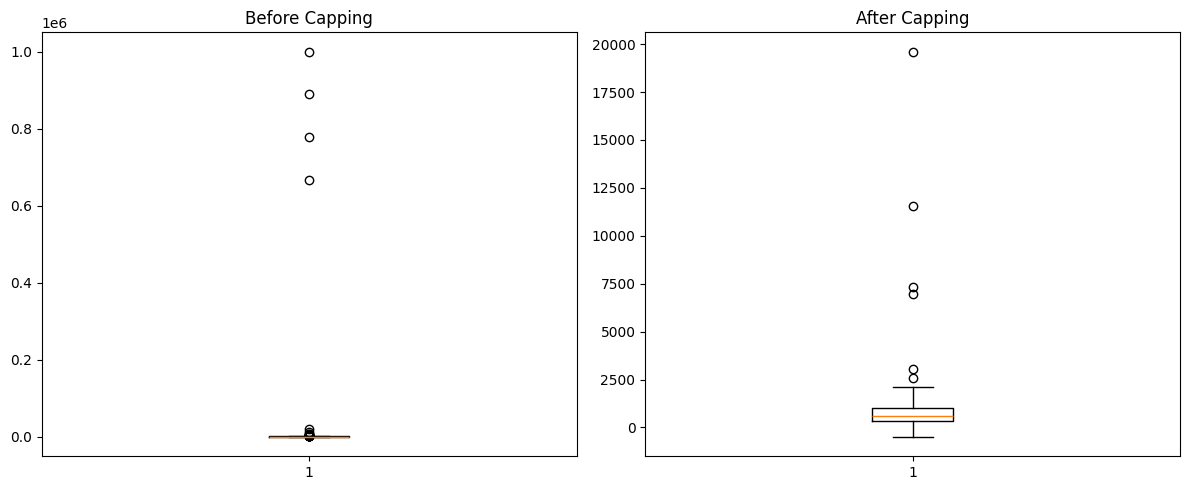

In [25]:
import matplotlib.pyplot as plt

# TODO 6.1: คำนวณ IQR เฉพาะรายการที่ไม่ใช่โปรโมชัน
non_promo = df[df['Is_Promotion'] != 'Y']['Transaction_Amount'].dropna()
Q1 = non_promo.quantile(0.25)
Q3 = non_promo.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# TODO 6.2: สร้าง Outlier Flag
df['Is_Outlier'] = (df['Is_Promotion'] != 'Y') & (
    (df['Transaction_Amount'] < lower_bound) | (df['Transaction_Amount'] > upper_bound)
)

# TODO 6.3: Capping ด้วย .clip()
df['Transaction_Amount_Cleaned'] = df['Transaction_Amount']
df.loc[df['Is_Promotion'] != 'Y', 'Transaction_Amount_Cleaned'] = \
    df.loc[df['Is_Promotion'] != 'Y', 'Transaction_Amount'].clip(lower_bound, upper_bound)

# TODO 6.4: วาด Boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot(df['Transaction_Amount'].dropna())
axes[0].set_title('Before Capping')
axes[1].boxplot(df['Transaction_Amount_Cleaned'].dropna())
axes[1].set_title('After Capping')
plt.tight_layout()
plt.show()



### คำถาม 5
เพราะเหตุใดข้อมูลที่อยู่นอก IQR Bound จึงไม่จำเป็นต้องเป็นข้อมูลผิดเสมอ? ยกตัวอย่างจาก Dataset นี้



ตอบ: เพราะ IQR เป็นเพียงเครื่องมือทางสถิติที่วัดการกระจายตัวของข้อมูลส่วนใหญ่ แต่นอกขอบเขตอาจเป็น พฤติกรรมจริงของลูกค้า (Genuine Business Variance) เช่น การซื้อสินค้าล็อตใหญ่ของลูกค้ารายใหญ่ (B2B Purchase) หรือการซื้อสินค้าช่วงแคมเปญโปรโมชันพิเศษ (Is_Promotion == 'Y') ที่มีการกว้านซื้อปริมาณมาก ยอด Transaction จึงสูงกว่าปกติโดยที่ไม่ใช่ข้อผิดพลาดของข้อมูล


## 7) Timeliness: ความทันเวลาในการโหลดข้อมูล

In [26]:
# TODO 7: คำนวณ Load_Delay_Hours
df['Load_Delay_Hours'] = (df['Load_Timestamp'] - pd.to_datetime(df['Order_Date'])).dt.total_seconds() / 3600
df['Is_Late_Load'] = df['Load_Delay_Hours'] > 24

late_count = df['Is_Late_Load'].sum()
late_pct = (late_count / len(df)) * 100
print(f"Late Loads: {late_count} ({late_pct:.2f}%)")

Late Loads: 48 (7.84%)


## 8) Data Quality Report และ Export

In [27]:
# TODO 8.1: สรุปตัวชี้วัดก่อนและหลัง Cleaning เป็น DataFrame
# อย่างน้อย: rows, missing email, exact duplicates, invalid dates, mismatched amounts,
# outliers capped, late loads และ invalid statuses

# Variables that need to be defined or corrected:
# exact_dupes_before: this was 18 as per previous execution of cell b605bdbf (df.duplicated().sum() before drop_duplicates)
exact_dupes_before = 18

# Gender and Payment_Method variants before cleaning
gender_variants_before = df_raw['Gender'].nunique()
payment_method_variants_before = df_raw['Payment_Method'].nunique()

# Order_Status non-standard rows before cleaning
valid_statuses_for_report = ['Completed', 'Pending', 'Cancelled', 'Refunded'] # Re-define as a local variable for clarity
order_status_non_standard_before = (~df_raw['Order_Status'].astype(str).str.strip().str.title().isin(valid_statuses_for_report)).sum()

report = pd.DataFrame([
    {'Metric': 'Total rows', 'Before': len(df_raw), 'After': len(df)},
    {'Metric': 'Exact duplicate rows', 'Before': int(exact_dupes_before), 'After': int(df.duplicated().sum())},
    {'Metric': 'Missing Customer_Email', 'Before': int(df['Is_Missing_Email'].sum()), 'After': int(df['Customer_Email'].isnull().sum())},
    {'Metric': 'Missing Province', 'Before': int(df['Is_Missing_Province'].sum()), 'After': int(df['Province'].isnull().sum())},
    {'Metric': 'Gender format variants', 'Before': gender_variants_before, 'After': int(df['Gender'].nunique())},
    {'Metric': 'Payment_Method format variants', 'Before': payment_method_variants_before, 'After': int(df['Payment_Method'].nunique())},
    {'Metric': 'Order_Date unparseable/invalid', 'Before': int(df['Is_Date_Fallback'].sum()), 'After': 0}, # After is 0 because all dates are now parsed
    {'Metric': 'Quantity outside business rule (1-20)', 'Before': int(df['Is_Invalid_Quantity'].sum()), 'After': int(df['Is_Invalid_Quantity'].sum())}, # No action to fix quantity directly, flag remains
    {'Metric': 'Accuracy mismatch (non-promo, >1 baht)', 'Before': int(df.loc[df['Is_Promotion']=='N','Accuracy_Flag'].sum()), 'After': int(df.loc[df['Is_Promotion']=='N','Accuracy_Flag'].sum())}, # No action to fix mismatch directly, flag remains
    {'Metric': 'Order_Status non-standard rows', 'Before': int(order_status_non_standard_before), 'After': int(df['Is_Invalid_Status'].sum())}, # Using Is_Invalid_Status for after standardization check
    {'Metric': 'Outliers outside IQR bound (non-promo)', 'Before': int(df['Is_Outlier'].sum()), 'After': int(df.loc[df['Is_Promotion'] != 'Y', 'Transaction_Amount_Cleaned'].apply(lambda x: x < lower_bound or x > upper_bound).sum())}, # Checks cleaned column, should be 0 or small
    {'Metric': 'Late loads (Load_Delay_Hours > 24h)', 'Before': int(df['Is_Late_Load'].sum()), 'After': int(df['Is_Late_Load'].sum())} # No action to fix late loads
])
display(report)

# TODO 8.2: Export
df.to_csv(OUTPUT_DIR / 'e_commerce_clean.csv', index=False, encoding='utf-8-sig')
report.to_csv(OUTPUT_DIR / 'data_quality_report.csv', index=False, encoding='utf-8-sig')
print()
print(f'Export สำเร็จ -> {OUTPUT_DIR}')

,Metric,Before,After
0,Total rows,630,612
1,Exact duplicate rows,18,0
2,Missing Customer_Email,48,0
3,Missing Province,12,0
4,Gender format variants,10,2
5,Payment_Method format variants,14,5
6,Order_Date unparseable/invalid,5,0
7,Quantity outside business rule (1-20),3,3
8,"Accuracy mismatch (non-promo, >1 baht)",43,43
9,Order_Status non-standard rows,320,308



Export สำเร็จ -> /content/outputs/student_submission


## 9) Reflection
ตอบเป็นย่อหน้าสั้น ๆ
1. ขั้นตอนใดมีความเสี่ยงทำให้ข้อมูลจริงสูญหายมากที่สุด?
การทำ Exact Duplicates Removal (drop_duplicates) และการทำ Data Imputation /
2. กฎใดควรนำไปทำ Automation ใน Data Pipeline? Format Schema Standard: การบังคับ Pattern วันที่ Business Accuracy Rule Check Range Checks & Outliers Warning:
3. หากใช้ Great Expectations คุณจะสร้าง Expectation ใดอย่างน้อย 3 ข้อ?
expect_column_values_to_not_be_null(column="Order_Date") — ตรวจสอบว่าวันที่สั่งซื้อต้องไม่เป็นค่าว่าง

expect_column_values_to_be_between(column="Quantity", min_value=1, max_value=20) — ควบคุมจำนวนสั่งซื้อให้อยู่ในช่วงที่กำหนดตามกฎธุรกิจ

expect_column_values_to_be_in_set(column="Order_Status", value_set=['Completed', 'Pending', 'Cancelled', 'Refunded']) — ตรวจสอบสถานะคำสั่งซื้อให้เป็นค่ามาตรฐานที่กำหนดไว้เท่านั้น


## Checklist ก่อนส่ง
- [ ] Notebook รันจากบนลงล่างได้โดยไม่ Error
- [ ] มีคำตอบคำถามทั้ง 5 ข้อและ Reflection
- [ ] ส่ง `e_commerce_clean.csv`
- [ ] ส่ง `data_quality_report.csv`
- [ ] ไม่ลบรายการโปรโมชันเพียงเพราะเป็น Outlier
